In [1]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc 
import time
import copy
import math
from torchvision.transforms import RandAugment

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchinfo
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from PIL import Image


import hashlib
import shutil
import ssl
import tempfile
import warnings
from pathlib import Path
from urllib.error import URLError
from urllib.parse import urlparse
from urllib.request import HTTPSHandler, Request, build_opener

import torch
import torch.nn as nn
from torch.hub import get_dir as get_torch_hub_dir
from torchvision import models
from torchvision.models import VGG16_Weights, vgg16

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:

base_path = 'LungHist700_combined/data/'
csv_path = base_path + 'data.csv'
images_base = base_path + 'images/' 

batch_size = 32
num_epochs = 100
learning_rate = 3e-4
random_seed = 42

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(random_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo em uso: {device}\n")

full_df = pd.read_csv(csv_path)
superclass_map = {'aca': 0, 'ssc': 1, 'scc': 1, 'nor': 2}
full_df['label'] = full_df['superclass'].map(superclass_map)

print("Dados carregados e mapeados com sucesso!")
print("Total de linhas:", len(full_df))
print("Colunas:", full_df.columns.tolist())
print("Exemplo das 5 primeiras linhas:\n", full_df.head())
print("Distribuição de resolução:\n", full_df['resolution'].value_counts())
print("Função de processamento de dados atualizada!")

Dispositivo em uso: cpu

Dados carregados e mapeados com sucesso!
Total de linhas: 691
Colunas: ['superclass', 'subclass', 'resolution', 'image_id', 'patient_id', 'label']
Exemplo das 5 primeiras linhas:
   superclass subclass resolution  image_id  patient_id  label
0        aca       bd        40x       901           1      0
1        aca       bd        40x       902           1      0
2        aca       bd        40x       903           1      0
3        aca       bd        40x       904           1      0
4        aca       bd        40x       905           1      0
Distribuição de resolução:
 resolution
20x    359
40x    332
Name: count, dtype: int64
Função de processamento de dados atualizada!


In [3]:
class LungHistDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):

        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        superclass = row['superclass']
        image_id = row['image_id']
        resolution = row['resolution']

        subclass = (
            row['subclass']
            if not pd.isna(row['subclass'])
            else ""
        )

        file_prefix = superclass

        if superclass == 'scc':

            folder_name = 'ssc'
            file_prefix = 'ssc'

        else:

            folder_name = superclass

        class_dir = os.path.join(
            self.root_dir,
            folder_name
        )

        potential_filenames = [

            f"{image_id}.jpg",

            f"{file_prefix}_{subclass}_{resolution}_{image_id}.jpg",

            f"{file_prefix}_{resolution}_{image_id}.jpg",

            f"{image_id}.png",

            f"{file_prefix}_{subclass}_{resolution}_{image_id}.png",

            f"{file_prefix}_{resolution}_{image_id}.png"
        ]

        img_path = None

        for fname in potential_filenames:

            full_path = os.path.join(
                class_dir,
                fname
            )

            if os.path.exists(full_path):

                img_path = full_path
                break

        if img_path is None and os.path.exists(class_dir):

            import glob

            search_pattern = os.path.join(
                class_dir,
                f"*{image_id}.*"
            )

            found_files = glob.glob(search_pattern)

            if found_files:

                img_path = found_files[0]

        try:

            if img_path is None:

                raise FileNotFoundError(
                    "Imagem não encontrada"
                )

            image = Image.open(img_path).convert("RGB")

        except Exception as e:

            print("\n" + "=" * 60)
            print("ERRO AO CARREGAR IMAGEM")
            print("=" * 60)

            print(f"ID: {image_id}")
            print(f"Classe: {superclass}")
            print(f"Resolution: {resolution}")
            print(f"Pasta: {class_dir}")
            print(f"Path encontrado: {img_path}")
            print(f"Erro: {e}")

            image = Image.new('RGB', (224, 224))

        label = row['label']

        if self.transform:

            image = self.transform(image)

        return image, label


print("✓ Classe Dataset definida com sucesso!")

✓ Classe Dataset definida com sucesso!


In [4]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Sem data aug configurado com sucesso.")

Sem data aug configurado com sucesso.


In [5]:
def print_stats_table(df_name, train_df, val_df, test_df):
    c_train = train_df['label'].value_counts().to_dict()
    c_val   = val_df['label'].value_counts().to_dict()
    c_test  = test_df['label'].value_counts().to_dict()
    idx_to_class = {0: 'ACA', 1: 'SCC', 2: 'NOR'}
    
    print(f"\nCONJUNTO DE DADOS: {df_name}")
    print("-" * 42)
    print(f"{'CLASSE':<8} | {'TREINO':<8} | {'VALIDAÇÃO':<8} | {'TESTE':<8}")
    print("-" * 42)
    for idx in range(3): 
        name = idx_to_class[idx]
        print(f"{name:<8} | {c_train.get(idx, 0):<8} | {c_val.get(idx, 0):<8} | {c_test.get(idx, 0):<8}")
    print("-" * 42 + "\n")

print("Função print_stats_table definida com sucesso!")

Função print_stats_table definida com sucesso!


In [6]:

def get_reproducible_ids(df, resolution):

    if resolution == '20x':
        train_ids = [2,3,4,5,7,8,12,14,15,16,17,18,20,21,23,24,25,26,28,29,30,33,36,37,38,39,41,42,45]
        val_ids   = [1,6,27,32,44]
        test_ids  = [9,13,31,40]

    elif resolution == '40x':
        train_ids = [2,6,8,9,10,12,13,14,16,18,19,21,22,24,28,29,31,33,34,35,36,38,40,44]
        val_ids   = [1,4,17,26,30,37,45]
        test_ids  = [11,15,20,25,32,43]

    else:
        raise ValueError("Resolution deve ser '20x' ou '40x'")

    train_df = df[df['patient_id'].isin(train_ids)]
    val_df   = df[df['patient_id'].isin(val_ids)]
    test_df  = df[df['patient_id'].isin(test_ids)]

    return train_df, val_df, test_df



def process_resolution(res):

    print(f"\n====================== {res.upper()} ======================")

   
    df_res = full_df[
        (full_df['resolution'] == res) &
        (full_df['superclass'].isin(['aca', 'nor', 'scc']))
    ].reset_index(drop=True)

    print(f"Dataset {res}: {len(df_res)} imagens")
    
    train_df, val_df, test_df = get_reproducible_ids(df_res, res)

    
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

  
    print("\n Classes por split:")
    for name, df_split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n{name.upper()}")
        print(df_split["superclass"].value_counts())

    print("\n🔎 Verificação de leakage:")
    print("train ∩ val :", set(train_df['patient_id']) & set(val_df['patient_id']))
    print("train ∩ test:", set(train_df['patient_id']) & set(test_df['patient_id']))
    print("val ∩ test :", set(val_df['patient_id']) & set(test_df['patient_id']))


    train_ds = LungHistDataset(train_df, images_base, transform=train_transform)
    val_ds   = LungHistDataset(val_df,   images_base, transform=val_test_transform)
    test_ds  = LungHistDataset(test_df,  images_base, transform=val_test_transform)


    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=False
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=False
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=False
    )

    print_stats_table(f"{res.upper()} (SPLIT FIXO POR PACIENTE)", train_df, val_df, test_df)

    return train_loader, val_loader, test_loader



train_loader_40x, val_loader_40x, test_loader_40x = process_resolution('40x')


====================== 40X ======================
Dataset 40x: 332 imagens

 Classes por split:

TRAIN
superclass
aca    101
scc     96
nor     39
Name: count, dtype: int64

VAL
superclass
aca    16
scc    16
nor    14
Name: count, dtype: int64

TEST
superclass
scc    20
aca    17
nor    13
Name: count, dtype: int64

🔎 Verificação de leakage:
train ∩ val : set()
train ∩ test: set()
val ∩ test : set()

CONJUNTO DE DADOS: 40X (SPLIT FIXO POR PACIENTE)
------------------------------------------
CLASSE   | TREINO   | VALIDAÇÃO | TESTE   
------------------------------------------
ACA      | 101      | 16       | 17      
SCC      | 96       | 16       | 20      
NOR      | 39       | 14       | 13      
------------------------------------------



In [7]:
def get_model(model_name, num_classes=3, feature_extract=True):
    model = None

    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'efficientnet_b3':
        weights = models.EfficientNet_B3_Weights.DEFAULT
        model = models.efficientnet_b3(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'densenet121':
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'convnext_tiny':

        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

       
        num_ftrs = model.classifier[2].in_features

        model.classifier[2] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

        # libera apenas o classifier
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == 'vit_b16':

        weights = models.ViT_B_16_Weights.DEFAULT
        model = models.vit_b_16(weights=weights)

        # congela tudo
        for param in model.parameters():
            param.requires_grad = False

        # libera últimas camadas do encoder
        for param in model.encoder.layers[-4:].parameters():
            param.requires_grad = True

        # cabeça
        num_ftrs = model.heads.head.in_features

        model.heads.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

        for param in model.heads.parameters():
            param.requires_grad = True
    return model.to(device)

In [8]:
#CONFG
def train_model(
    model,
    dataloaders,
    criterion,
    num_epochs=100,
    save_name='best_model.pth',
    model_name='MODEL',

    learning_rate=3e-4,
    weight_decay=1e-4,

    optimizer_name="adamw",
    scheduler_name="cosine",

    scheduler_step_size=10,
    scheduler_gamma=0.1,
    scheduler_t_max=35,
    min_learning_rate=1e-6,

    early_stopping_patience=15
):

    since = time.time()

    val_acc_history = []
    train_loss_history = []
    val_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    epochs_no_improve = 0

    
    if optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay
        )

    else:
        raise ValueError(f"Optimizer '{optimizer_name}' não suportado.")


    if scheduler_name == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=scheduler_t_max,
            eta_min=min_learning_rate
        )

    elif scheduler_name == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=scheduler_step_size,
            gamma=scheduler_gamma
        )

    elif scheduler_name == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=scheduler_gamma,
            patience=5
        )

    else:
        scheduler = None

    print(f"\n🚀 START TRAINING {model_name}")
    print(f"🧠 Early Stopping patience = {early_stopping_patience}")

    
    for epoch in range(num_epochs):

        print(f'\nEpoch {epoch+1:02d}/{num_epochs}')

        epoch_val_loss = None
        improved = False

        for phase in ['train', 'val']:

            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):

                    outputs = model(inputs)

                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)

            epoch_acc = (
                running_corrects.double() /
                len(dataloaders[phase].dataset)
            )

            print(
                f"  {phase.upper()} → "
                f"Loss: {epoch_loss:.4f} | "
                f"Acc: {epoch_acc:.4f}"
            )

         

            if phase == 'train':

                train_loss_history.append(epoch_loss)

            else:

                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())

                epoch_val_loss = epoch_loss

               

                if epoch_acc > best_acc:

                    best_acc = epoch_acc.item()

                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

                    torch.save(
                        model.state_dict(),
                        save_name
                    )

                    print(
                        f"  BEST MODEL SAVED | "
                        f"Acc: {best_acc:.4f}"
                    )

                    improved = True

     

        if improved:
            epochs_no_improve = 0

        else:
            epochs_no_improve += 1

            print(
                f" No improvement for "
                f"{epochs_no_improve} epochs"
            )

        if epochs_no_improve >= early_stopping_patience:

            print(
                f"\n EARLY STOPPING TRIGGERED "
                f"(patience={early_stopping_patience})"
            )

            break



        if scheduler:

            if isinstance(
                scheduler,
                torch.optim.lr_scheduler.ReduceLROnPlateau
            ):

                scheduler.step(epoch_val_loss)

            else:
                scheduler.step()

        print(
            f"    LR atual: "
            f"{optimizer.param_groups[0]['lr']:.6f}"
        )



    time_elapsed = time.time() - since

    print(
        f'\nTraining complete in '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )

    print(f' Best Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)

    history = {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'val_acc': val_acc_history
    }

    return model, history, best_acc

In [9]:
# MODELS 
model_names = [
    'resnet50',
    'efficientnet_b3',
    'densenet121',
    'vit_b16',
    'convnext_tiny' 
]

sample_images, sample_labels = next(iter(train_loader_40x))

real_input_shape = sample_images.shape

print(f"Tamanho real do input obtido: {real_input_shape}")

for name in model_names:

    print(f"\n   ➤ MODELO: {name.upper()}")

    model_temp = get_model(
        name,
        num_classes=3,
        feature_extract=False
    )

    summary(
        model_temp,
        input_size=real_input_shape,
        col_names=[
            "input_size",
            "output_size",
            "num_params",
            "mult_adds"
        ],
        depth=1,
        verbose=1
    )

    del model_temp

    gc.collect()

    torch.cuda.empty_cache()

/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tamanho real do input obtido: torch.Size([32, 3, 224, 224])

   ➤ MODELO: RESNET50
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
ResNet                                   [32, 3, 224, 224]         [32, 3]                   --                        --
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        9,408                     3,776,446,464
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        128                       4,096
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 256, 56, 56]         215,808                   21,374,263,296
├─Sequential: 1-6             

In [10]:
import os
import gc
import pickle
import torch
import torch.nn as nn

SAVE_DIR = "Best_models"
os.makedirs(SAVE_DIR, exist_ok=True)

model_names = [
    'resnet50',
    'efficientnet_b3',
    'densenet121',
    'vit_b16',
    'convnext_tiny'
]

results_40x = {}
histories_40x = {}
trained_models_40x = {}

criterion = nn.CrossEntropyLoss()

print(">>> INICIANDO COMPARAÇÃO DOS MODELOS NO DATASET 40X")
print(f"ÉPOCAS: {num_epochs}")
print(f"BATCH SIZE: {batch_size}")
print(f"LEARNING RATE: 3e-4")
print("=" * 70)

for i, name in enumerate(model_names):

    loaders_40x = {
        'train': train_loader_40x,
        'val': val_loader_40x
    }

    print("\n" + "=" * 70)
    print(f"MODELO: {name.upper()}")
    print("=" * 70)

    save_path = os.path.join(
        SAVE_DIR,
        f"best_Rand_{name}_40x.pth"
    )

    history_path = os.path.join(
        SAVE_DIR,
        f"history_{name}_40x.pkl"
    )

    done_path = os.path.join(
        SAVE_DIR,
        f"{name}_40x.done"
    )

    if os.path.exists(done_path):

        print(f"[{name.upper()}] JÁ TREINADO -> PULANDO")

        try:

            model = get_model(
                name,
                num_classes=3,
                feature_extract=False
            )
            model = model.to(device)

            model.load_state_dict(torch.load(save_path, map_location=device))

            model.eval()
            trained_models_40x[name] = model

            if os.path.exists(history_path):

                with open(history_path, 'rb') as f:
                    histories_40x[name] = pickle.load(f)

            print(f"[{name.upper()}] PESOS CARREGADOS!")

        except Exception as e:

            print(f"ERRO AO CARREGAR {name}: {e}")

        continue

    try:


        print(f"[{name.upper()}] INICIANDO TREINAMENTO...")

        model = get_model(
            name,
            num_classes=3,
            feature_extract=False
        )
        model = model.to(device)

        model, hist, best_acc = train_model(
            model=model,
            dataloaders=loaders_40x,

            criterion=criterion,

            num_epochs=num_epochs,

            save_name=save_path,

            model_name=name.upper(),

            learning_rate=3e-4,
            weight_decay=1e-4,

            optimizer_name="adamw",

            scheduler_name="cosine",

            scheduler_t_max=35,

            min_learning_rate=1e-6,

            early_stopping_patience=15
        )

        results_40x[name] = best_acc
        histories_40x[name] = hist
        trained_models_40x[name] = model

        with open(history_path, 'wb') as f:
            pickle.dump(hist, f)

        with open(done_path, 'w') as f:
            f.write("finished")

        print(f"[{name.upper()}] TREINAMENTO FINALIZADO!")
        print(f"BEST ACC: {best_acc:.4f}")

    except Exception as e:

        print("\n" + "-" * 70)
        print(f"ERRO DURANTE O TREINAMENTO DE {name.upper()}")
        print(e)
        print("-" * 70)

    finally:

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\n" + "=" * 70)
print("RESUMO FINAL DAS ACURÁCIAS (40X)")
print("=" * 70)

for name, acc in results_40x.items():

    print(f"{name:<20}: {acc:.4f}")

print("=" * 70)

with open('histories_sem_40x.pkl', 'wb') as f:
    pickle.dump(histories_40x, f)

print("\nHistóricos salvos com sucesso!")
print(histories_40x.keys())

>>> INICIANDO COMPARAÇÃO DOS MODELOS NO DATASET 40X
ÉPOCAS: 100
BATCH SIZE: 32
LEARNING RATE: 3e-4

MODELO: RESNET50
[RESNET50] JÁ TREINADO -> PULANDO
[RESNET50] PESOS CARREGADOS!

MODELO: EFFICIENTNET_B3
[EFFICIENTNET_B3] JÁ TREINADO -> PULANDO
[EFFICIENTNET_B3] PESOS CARREGADOS!

MODELO: DENSENET121
[DENSENET121] JÁ TREINADO -> PULANDO
[DENSENET121] PESOS CARREGADOS!

MODELO: VIT_B16
[VIT_B16] JÁ TREINADO -> PULANDO
[VIT_B16] PESOS CARREGADOS!

MODELO: CONVNEXT_TINY
[CONVNEXT_TINY] JÁ TREINADO -> PULANDO
[CONVNEXT_TINY] PESOS CARREGADOS!

RESUMO FINAL DAS ACURÁCIAS (40X)

Históricos salvos com sucesso!
dict_keys(['resnet50', 'efficientnet_b3', 'densenet121', 'vit_b16', 'convnext_tiny'])


In [11]:
import pickle

with open('histories_sem_40x.pkl', 'rb') as f:
    histories_40x = pickle.load(f)

print(histories_40x.keys())

dict_keys(['resnet50', 'efficientnet_b3', 'densenet121', 'vit_b16', 'convnext_tiny'])


In [12]:
histories_40x['resnet50'].keys()

dict_keys(['train_loss', 'val_loss', 'val_acc'])

In [13]:
best_val_acc = {model: max(histories_40x[model]['val_acc']) for model in histories_40x}

print(best_val_acc)

{'resnet50': 0.5869565217391305, 'efficientnet_b3': 0.5652173913043478, 'densenet121': 0.7608695652173914, 'vit_b16': 0.8260869565217391, 'convnext_tiny': 0.5}




GRÁFICO DE COMPARAÇÃO DO DATASET 40X


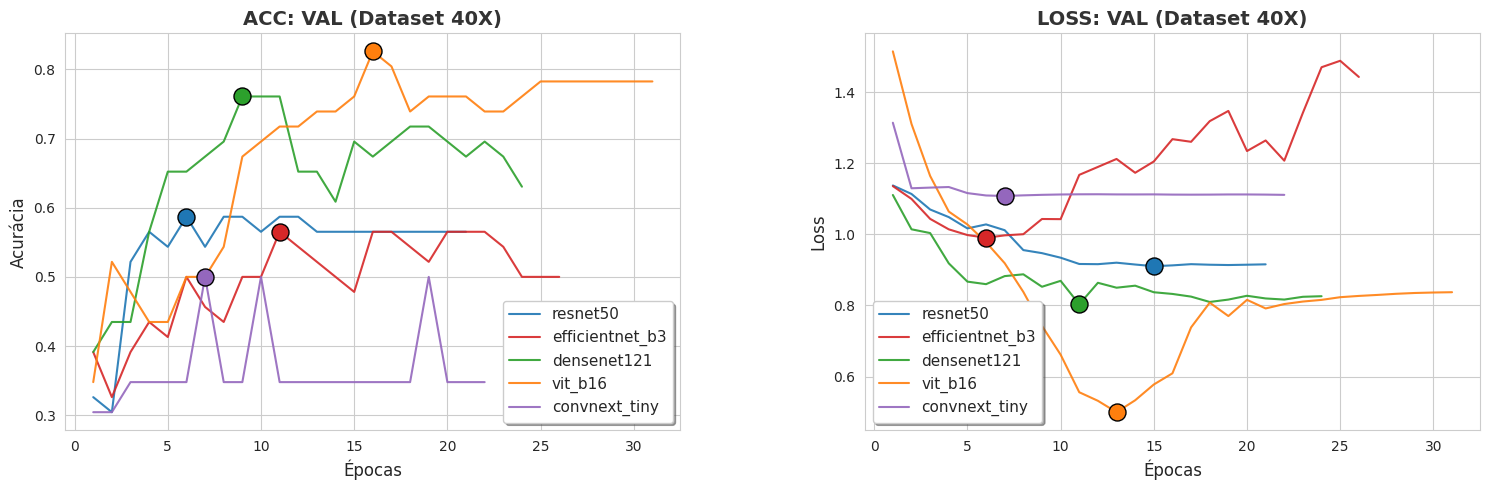

In [14]:

def plot_line_chart_comparison(histories, title_suffix=""):
    sns.set_style("whitegrid") 
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    

    ax1 = axes[0]
    for i, (name, hist) in enumerate(histories.items()):
        val_acc = hist['val_acc']
        epochs = range(1, len(val_acc) + 1)

        ax1.plot(
            epochs,
            val_acc,
            label=name,
            color=colors[i % len(colors)],
            linewidth=1.5,
            linestyle='-',
            alpha=0.9
        )

        best_val = max(val_acc)
        best_epoch = val_acc.index(best_val) + 1

        ax1.scatter(
            best_epoch,
            best_val,
            s=150,
            c=colors[i],
            edgecolors='k',
            zorder=10
        )

    ax1.set_title(f'ACC: VAL {title_suffix}', fontsize=14, fontweight='bold', color='#333333')
    ax1.set_xlabel('Épocas', fontsize=12)
    ax1.set_ylabel('Acurácia', fontsize=12)
    ax1.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)

    ax2 = axes[1]
    for i, (name, hist) in enumerate(histories.items()):
        val_loss = hist['val_loss']
        epochs = range(1, len(val_loss) + 1)

        ax2.plot(
            epochs,
            val_loss,
            label=name,
            color=colors[i % len(colors)],
            linewidth=1.5,
            linestyle='-',
            alpha=0.9
        )

        min_loss = min(val_loss)
        best_epoch_loss = val_loss.index(min_loss) + 1

        ax2.scatter(
            best_epoch_loss,
            min_loss,
            s=150,
            c=colors[i],
            edgecolors='k',
            zorder=10
        )

    ax2.set_title(f'LOSS: VAL {title_suffix}', fontsize=14, fontweight='bold', color='#333333')
    ax2.set_xlabel('Épocas', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()



print(f"\n\nGRÁFICO DE COMPARAÇÃO DO DATASET 40X")
plot_line_chart_comparison(histories_40x, title_suffix="(Dataset 40X)")

In [15]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluate_model_full(
    model,
    loader,
    model_name,
    dataset_name,
    class_names=['ACA', 'SCC', 'NOR'],
    save_dir="results_semRand"
):

    model.eval()

    y_true = []
    y_pred = []
    y_probs = []

    print(f"\nRELATÓRIO: {model_name.upper()} ({dataset_name})")

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            outputs = torch.nan_to_num(
                outputs,
                nan=0.0,
                posinf=10.0,
                neginf=-10.0
            )

            _, preds = torch.max(outputs, 1)

            probs = F.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)

    y_probs = np.nan_to_num(
        y_probs,
        nan=1.0 / len(class_names)
    )

    acc = accuracy_score(y_true, y_pred)

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )
    try:
        y_true_np = np.array(y_true)
        y_probs_np = np.array(y_probs)

        unique_classes = np.unique(y_true_np)
        expected_classes = np.arange(len(class_names))

        # Verifica se todas as classes estão presentes
        if len(unique_classes) < len(class_names):
            raise ValueError(
                f"Classes ausentes em y_true. "
                f"Esperado: {expected_classes}, Encontrado: {unique_classes}"
            )

        # Verifica consistência de shape
        if y_probs_np.shape[1] != len(class_names):
            raise ValueError(
                f"Incompatibilidade: y_probs tem {y_probs_np.shape[1]} colunas, "
                f"mas existem {len(class_names)} classes"
            )

        roc_auc = roc_auc_score(
            y_true_np,
            y_probs_np,
            multi_class='ovr',
            average='weighted'
        )

    except Exception as e:
        print(f"⚠️ ERRO ROC-AUC: {e}")
        print(
            f"Shape y_probs: {y_probs_np.shape} | "
            f"Classes em y_true: {unique_classes}"
        )

        # Melhor que 0.0 → não contamina média depois
        roc_auc = np.nan

    print(
        f"➤ RESULTADO: "
        f"Accuracy: {acc:.4f} | "
        f"ROC-AUC: {roc_auc:.4f} | "
        f"Kappa: {kappa:.4f}\n"
    )

    print("RELATÓRIO DE CLASSIFICAÇÃO:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    print("\nMATRIZ DE CONFUSÃO:")
    print(cm)

    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")

    plt.title(f"Matriz de Confusão - {model_name} ({dataset_name})")

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/cm_{model_name}_{dataset_name}.png",
        dpi=300
    )

    plt.close()

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")

    plt.title(f"Matriz Normalizada - {model_name} ({dataset_name})")

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/cm_norm_{model_name}_{dataset_name}.png",
        dpi=300
    )

    plt.close()

    print(f"✔ Matrizes salvas em: {save_dir}/")

    print("-" * 85)

    return acc, roc_auc, kappa, cm

In [16]:
print("RESULTADOS DA AVALIAÇÃO (DATASET 40X)")

for name, model in trained_models_40x.items():

    evaluate_model_full(
        model=model,
        loader=test_loader_40x,
        model_name=name,
        dataset_name="40x"
    )

RESULTADOS DA AVALIAÇÃO (DATASET 40X)

RELATÓRIO: RESNET50 (40x)
➤ RESULTADO: Accuracy: 0.5800 | ROC-AUC: 0.7698 | Kappa: 0.3321

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.5417    0.7647    0.6341        17
         SCC     0.6154    0.8000    0.6957        20
         NOR     0.0000    0.0000    0.0000        13

    accuracy                         0.5800        50
   macro avg     0.3857    0.5216    0.4433        50
weighted avg     0.4303    0.5800    0.4939        50


MATRIZ DE CONFUSÃO:
[[13  4  0]
 [ 4 16  0]
 [ 7  6  0]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: EFFICIENTNET_B3 (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.6200 | ROC-AUC: 0.9136 | Kappa: 0.4256

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.0000    0.0000    0.0000        17
         SCC     0.6429    0.9000    0.7500        20
         NOR     0.5909    1.0000    0.7429        13

    accuracy                         0.6200        50
   macro avg     0.4113    0.6333    0.4976        50
weighted avg     0.4108    0.6200    0.4931        50


MATRIZ DE CONFUSÃO:
[[ 0 10  7]
 [ 0 18  2]
 [ 0  0 13]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: DENSENET121 (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.6600 | ROC-AUC: 0.7431 | Kappa: 0.4848

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.5909    0.7647    0.6667        17
         SCC     0.7500    0.6000    0.6667        20
         NOR     0.6667    0.6154    0.6400        13

    accuracy                         0.6600        50
   macro avg     0.6692    0.6600    0.6578        50
weighted avg     0.6742    0.6600    0.6597        50


MATRIZ DE CONFUSÃO:
[[13  1  3]
 [ 7 12  1]
 [ 2  3  8]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: VIT_B16 (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.8800 | ROC-AUC: 0.9923 | Kappa: 0.8211

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.9412    0.9412    0.9412        17
         SCC     1.0000    0.7500    0.8571        20
         NOR     0.7222    1.0000    0.8387        13

    accuracy                         0.8800        50
   macro avg     0.8878    0.8971    0.8790        50
weighted avg     0.9078    0.8800    0.8809        50


MATRIZ DE CONFUSÃO:
[[16  0  1]
 [ 1 15  4]
 [ 0  0 13]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: CONVNEXT_TINY (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.4200 | ROC-AUC: 0.7231 | Kappa: 0.1082

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.3571    0.8824    0.5085        17
         SCC     0.7500    0.3000    0.4286        20
         NOR     0.0000    0.0000    0.0000        13

    accuracy                         0.4200        50
   macro avg     0.3690    0.3941    0.3123        50
weighted avg     0.4214    0.4200    0.3443        50


MATRIZ DE CONFUSÃO:
[[15  2  0]
 [14  6  0]
 [13  0  0]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------


In [17]:
#recaregar modelos
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_names = ['resnet50', 'efficientnet_b3', 'densenet121', 'vit_b16', 'convnext_tiny' ]

trained_models_40x = {}

print("="*60)
print("CARREGANDO MODELOS 40X")
print("="*60)

for name in model_names:

    print(f"\nCarregando {name.upper()}...")

    model = get_model(
        model_name=name,
        num_classes=3,
        feature_extract=False
    )
    model = model.to(device)
    
    path = f"Best_models/best_Rand_{name}_40x.pth"

    model.load_state_dict(
        torch.load(path, map_location=device)
    )

    model.to(device)
    model.eval()

    trained_models_40x[name] = model

    print(f"{name.upper()} carregado com sucesso!")

print("\n" + "="*60)
print("TODOS OS MODELOS 40X FORAM CARREGADOS!")
print("="*60)

print("\nRESULTADOS DA AVALIAÇÃO (DATASET 40X)")

for name, model in trained_models_40x.items():

    evaluate_model_full(
        model=model,
        loader=test_loader_40x,
        model_name=name,
        dataset_name="40x"
    )

CARREGANDO MODELOS 40X

Carregando RESNET50...
RESNET50 carregado com sucesso!

Carregando EFFICIENTNET_B3...
EFFICIENTNET_B3 carregado com sucesso!

Carregando DENSENET121...
DENSENET121 carregado com sucesso!

Carregando VIT_B16...
VIT_B16 carregado com sucesso!

Carregando CONVNEXT_TINY...
CONVNEXT_TINY carregado com sucesso!

TODOS OS MODELOS 40X FORAM CARREGADOS!

RESULTADOS DA AVALIAÇÃO (DATASET 40X)

RELATÓRIO: RESNET50 (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.5800 | ROC-AUC: 0.7698 | Kappa: 0.3321

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.5417    0.7647    0.6341        17
         SCC     0.6154    0.8000    0.6957        20
         NOR     0.0000    0.0000    0.0000        13

    accuracy                         0.5800        50
   macro avg     0.3857    0.5216    0.4433        50
weighted avg     0.4303    0.5800    0.4939        50


MATRIZ DE CONFUSÃO:
[[13  4  0]
 [ 4 16  0]
 [ 7  6  0]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: EFFICIENTNET_B3 (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.6200 | ROC-AUC: 0.9136 | Kappa: 0.4256

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.0000    0.0000    0.0000        17
         SCC     0.6429    0.9000    0.7500        20
         NOR     0.5909    1.0000    0.7429        13

    accuracy                         0.6200        50
   macro avg     0.4113    0.6333    0.4976        50
weighted avg     0.4108    0.6200    0.4931        50


MATRIZ DE CONFUSÃO:
[[ 0 10  7]
 [ 0 18  2]
 [ 0  0 13]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: DENSENET121 (40x)


...

➤ RESULTADO: Accuracy: 0.6600 | ROC-AUC: 0.7431 | Kappa: 0.4848

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.5909    0.7647    0.6667        17
         SCC     0.7500    0.6000    0.6667        20
         NOR     0.6667    0.6154    0.6400        13

    accuracy                         0.6600        50
   macro avg     0.6692    0.6600    0.6578        50
weighted avg     0.6742    0.6600    0.6597        50


MATRIZ DE CONFUSÃO:
[[13  1  3]
 [ 7 12  1]
 [ 2  3  8]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: VIT_B16 (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.8800 | ROC-AUC: 0.9923 | Kappa: 0.8211

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.9412    0.9412    0.9412        17
         SCC     1.0000    0.7500    0.8571        20
         NOR     0.7222    1.0000    0.8387        13

    accuracy                         0.8800        50
   macro avg     0.8878    0.8971    0.8790        50
weighted avg     0.9078    0.8800    0.8809        50


MATRIZ DE CONFUSÃO:
[[16  0  1]
 [ 1 15  4]
 [ 0  0 13]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------

RELATÓRIO: CONVNEXT_TINY (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.4200 | ROC-AUC: 0.7231 | Kappa: 0.1082

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.3571    0.8824    0.5085        17
         SCC     0.7500    0.3000    0.4286        20
         NOR     0.0000    0.0000    0.0000        13

    accuracy                         0.4200        50
   macro avg     0.3690    0.3941    0.3123        50
weighted avg     0.4214    0.4200    0.3443        50


MATRIZ DE CONFUSÃO:
[[15  2  0]
 [14  6  0]
 [13  0  0]]
✔ Matrizes salvas em: results_semRand/
-------------------------------------------------------------------------------------


In [18]:
#ACERTOS
IMG_SIZE = 2.6


def get_target_layer(model, model_name):

    name_lower = model_name.lower()

    if 'resnet' in name_lower:
        return [model.layer4[-1]], None

    elif 'efficientnet' in name_lower:
        return [model.features[-1]], None

    elif 'densenet' in name_lower:
        return [model.features[-1]], None

    elif 'vgg' in name_lower:
        return [model.features[-1]], None

    elif 'convnext' in name_lower:
        return [model.features[-1]], None

    elif 'vit' in name_lower:

        def reshape_transform(tensor):

            tensor = tensor[:, 1:, :]

            height = width = int(tensor.size(1) ** 0.5)

            result = tensor.reshape(
                tensor.size(0),
                height,
                width,
                tensor.size(2)
            )

            result = result.transpose(2, 3).transpose(1, 2)

            return result

        return [model.encoder.layers[-1].ln_1], reshape_transform

    else:
        raise ValueError(f"Modelo não suportado: {model_name}")


def denormalize_image(tensor):

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img = tensor.permute(1, 2, 0).cpu().numpy()

    img = (img * std) + mean

    img = np.clip(img, 0, 1)

    return img


def visualize_3_classes_correct(
    model,
    model_name,
    loader,
    device
):

    class_names = {
        0: "ACA",
        1: "SCC",
        2: "NOR"
    }

    model.eval()

    target_layers = get_target_layer(model, model_name)

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    found_images = {}

    needed_classes = [0, 1, 2]

    print("=" * 70)
    print(f"GRAD-CAM → {model_name.upper()}")
    print("=" * 70)

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            preds = torch.argmax(outputs, dim=1)

            for i in range(len(labels)):

                true_label = labels[i].item()
                pred_label = preds[i].item()

                if true_label == pred_label:

                    if true_label not in found_images:

                        found_images[true_label] = (
                            inputs[i].detach().cpu(),
                            true_label,
                            pred_label
                        )

            if len(found_images) == 3:
                break

    print("\nClasses encontradas:")

    for cls in sorted(found_images.keys()):
        print(f"✓ {class_names[cls]}")

    if len(found_images) < 3:

        print("\n⚠ Algumas classes não foram encontradas.")
        print("- a classe não existe no test_loader")
        print("- ou não houve predição correta")

    ordered_selection = []

    for cls in needed_classes:

        if cls in found_images:
            ordered_selection.append(found_images[cls])

    original_images = []
    heatmap_images = []

    titles_original = []
    titles_heatmap = []

    for img_tensor, label_idx, pred_idx in ordered_selection:

        input_tensor = img_tensor.unsqueeze(0).to(device)

        targets = [ClassifierOutputTarget(pred_idx)]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        rgb_img = denormalize_image(img_tensor)

        rgb_img = rgb_img.astype(np.float32)

        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True,
            image_weight=0.7
        )

        original_images.append(rgb_img)
        heatmap_images.append(visualization)

        titles_original.append(
            f"TRUE: {class_names[label_idx]}"
        )

        titles_heatmap.append(
            f"PRED: {class_names[pred_idx]}"
        )

    num_cols = len(ordered_selection)

    fig, axes = plt.subplots(
        2,
        num_cols,
        figsize=(num_cols * IMG_SIZE, 2 * IMG_SIZE)
    )

    if num_cols == 1:
        axes = axes.reshape(2, 1)

    for i in range(num_cols):

        axes[0, i].imshow(original_images[i])

        axes[0, i].set_title(
            titles_original[i],
            fontsize=12,
            fontweight='bold'
        )

        axes[0, i].axis("off")

    for i in range(num_cols):

        axes[1, i].imshow(heatmap_images[i])

        axes[1, i].set_title(
            titles_heatmap[i],
            fontsize=12,
            fontweight='bold',
            color='green'
        )

        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close()



best_models_40x = ['resnet50', 'efficientnet_b3', 'densenet121', 'vit_b16', 'convnext_tiny' ]

In [19]:
print("\n" + "=" * 80)
print("GRAD-CAM → DATASET 40X")
print("=" * 80)

for model_name in best_models_40x:

    print("\n" + "-" * 70)
    print(f"MODELO → {model_name.upper()}")
    print("-" * 70)

    model = trained_models_40x[model_name]

    visualize_3_classes_correct(
        model=model,
        model_name=model_name,
        loader=test_loader_40x,
        device=device
    )

    torch.cuda.empty_cache()


GRAD-CAM → DATASET 40X

----------------------------------------------------------------------
MODELO → RESNET50
----------------------------------------------------------------------


AttributeError: 'list' object has no attribute 'register_forward_hook'

In [ ]:
#ERRO

IMG_SIZE = 3


def get_target_layer(model, model_name):

    name_lower = model_name.lower()

    if 'resnet' in name_lower:
        return [model.layer4[-1]], None

    elif 'efficientnet' in name_lower:
        return [model.features[-1]], None

    elif 'densenet' in name_lower:
        return [model.features[-1]], None

    elif 'vgg' in name_lower:
        return [model.features[-1]], None

    elif 'convnext' in name_lower:
        return [model.features[-1]], None

    elif 'vit' in name_lower:

        def reshape_transform(tensor):

            tensor = tensor[:, 1:, :]

            height = width = int(tensor.size(1) ** 0.5)

            result = tensor.reshape(
                tensor.size(0),
                height,
                width,
                tensor.size(2)
            )

            result = result.transpose(2, 3).transpose(1, 2)

            return result

        return [model.encoder.layers[-1].ln_1], reshape_transform

    else:
        raise ValueError(
            f"Modelo não suportado: {model_name}"
        )


def denormalize_image(tensor):

    mean = np.array([0.485, 0.456, 0.406])

    std = np.array([0.229, 0.224, 0.225])

    img = tensor.permute(1, 2, 0).cpu().numpy()

    img = (img * std) + mean

    img = np.clip(img, 0, 1)

    return img


def visualize_errors_top_bottom(
    model,
    model_name,
    loader,
    device
):

    class_names = {
        0: "ACA",
        1: "SCC",
        2: "NOR"
    }

    model.eval()

    target_layers = get_target_layer(
        model,
        model_name
    )

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    wrong_predictions = []

    print("=" * 70)
    print(f"ERROR ANALYSIS → {model_name.upper()}")
    print("=" * 70)

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            outputs = model(inputs)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            for i in range(len(labels)):

                true_label = labels[i].item()

                pred_label = preds[i].item()

                if true_label != pred_label:

                    wrong_predictions.append(
                        (
                            inputs[i].detach().cpu(),
                            true_label,
                            pred_label
                        )
                    )

    total_errors = len(wrong_predictions)

    if total_errors == 0:

        print("\n✓ Nenhuma predição incorreta encontrada.")

        return

    print(f"\n➤ Total de erros encontrados: {total_errors}")

    images_per_row = 6

    num_blocks = math.ceil(
        total_errors / images_per_row
    )

    total_plot_rows = num_blocks * 2

    fig, axes = plt.subplots(
        total_plot_rows,
        images_per_row,
        figsize=(
            images_per_row * IMG_SIZE,
            total_plot_rows * IMG_SIZE
        )
    )

    if total_plot_rows == 1:

        axes = axes.reshape(1, -1)

    if images_per_row == 1:

        axes = axes.reshape(-1, 1)

    if len(axes.shape) == 1:

        axes = axes.reshape(
            -1,
            images_per_row
        )

    for ax in axes.flatten():

        ax.axis("off")

    for i, (
        img_tensor,
        label_idx,
        pred_idx
    ) in enumerate(wrong_predictions):

        block_idx = i // images_per_row

        col_idx = i % images_per_row

        row_original = block_idx * 2

        row_heatmap = block_idx * 2 + 1

        input_tensor = img_tensor.unsqueeze(0).to(device)

        targets = [
            ClassifierOutputTarget(pred_idx)
        ]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        rgb_img = denormalize_image(
            img_tensor
        )

        rgb_img = rgb_img.astype(np.float32)

        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True,
            image_weight=0.7
        )

        true_class = class_names[label_idx]

        pred_class = class_names[pred_idx]

        axes[row_original, col_idx].imshow(
            rgb_img
        )

        axes[row_original, col_idx].set_title(
            f"TRUE: {true_class}",
            fontsize=12,
            fontweight='bold',
            color='black'
        )

        axes[row_original, col_idx].axis("off")

        axes[row_heatmap, col_idx].imshow(
            visualization
        )

        axes[row_heatmap, col_idx].set_title(
            f"PRED: {pred_class}",
            fontsize=12,
            fontweight='bold',
            color='red'
        )

        axes[row_heatmap, col_idx].axis("off")

    plt.tight_layout()

    plt.subplots_adjust(
        wspace=0.1,
        hspace=0.3
    )

    plt.show()

    plt.close()




best_models_40x = ['resnet50', 'efficientnet_b3', 'densenet121', 'vit_b16', 'convnext_tiny' ]


In [ ]:
print("\n" + "=" * 100)
print("ERROR ANALYSIS REPORT → DATASET 40X")
print("=" * 100)

for model_name in best_models_40x:

    print("\n" + "-" * 80)
    print(f"MODEL → {model_name.upper()}")
    print("-" * 80)

    visualize_errors_top_bottom(
        model=trained_models_40x[model_name],
        model_name=model_name,
        loader=test_loader_40x,
        device=device
    )